# **Over Sampling**

Over sampling adalah teknik dalam machine learning atau data mining yang digunakan untuk menyeimbangkan dataset yang tidak seimbang (imbalanced dataset). Dataset tidak seimbang terjadi ketika jumlah data di satu kelas jauh lebih sedikit dibanding kelas lainnya.

Over sampling menambah jumlah data pada kelas minoritas sehingga jumlahnya menjadi lebih seimbang dengan kelas mayoritas.

## **Tujuan**

1. Menganalisis distribusi kelas dalam dataset ecoli
2. Memvisualkan data dalam scatter plot  menggunakan PCA.PCA mentransformasi data menjadi dimensi rendah (2).
3. Mengaplikasikan teknik ADASYN untuk menyeimbangkan data
4. Memvisualisasikan hasil sebelum dan sesudah ADASYN
5. Membandingkan distribusi data menggunakan PCA dan LDA

## **Pengenalan Dataset**

- Menampilkan semua isi dari dataset ecoli untuk memahami struktur data.

In [2]:
import pandas as pd


df = pd.read_csv('ecoli.data')
print("Isi tabel ecoli:\n")
print(df.head())

Isi tabel ecoli:

  AAT_ECOLI   0.49  0.29  0.48  0.50  0.56  0.24  0.35   cp
0  ACEA_ECOLI  0.07  0.40  0.48  0.50  0.54  0.35...       
1  ACEK_ECOLI  0.56  0.40  0.48  0.50  0.49  0.37...       
2  ACKA_ECOLI  0.59  0.49  0.48  0.50  0.52  0.45...       
3  ADI_ECOLI   0.23  0.32  0.48  0.50  0.55  0.25...       
4  ALKH_ECOLI  0.67  0.39  0.48  0.50  0.36  0.38...       


## **Analisis Distribusi Kelas**

Lakukan analisis awal untuk mengidentifikasi ketidakseimbangan kelas :

1. Hitung banyaknya sampel untuk masing-masing spesies menggunakan value_counts().

2. Tentukan kelas yang termasuk minoritas dan mayoritas.

3. Hasil analisis ini akan membantu mengetahui apakah dataset perlu dilakukan penyeimbangan.

In [3]:
import pandas as pd
import io

column_names = ['sequence_name', 'mcg', 'gvh', 'lip', 'chg', 'aac', 'alm1', 'alm2', 'class']
df = pd.read_csv('ecoli.data', delim_whitespace=True, header=None, names=column_names)

# Menghitung jumlah pada tiap kelas di kolom 'class'
class_counts = df['class'].value_counts()

print("Jumlah pada tiap kelas di kolom 'class':")
print(class_counts)

Jumlah pada tiap kelas di kolom 'class':
class
cp     143
im      77
pp      52
imU     35
om      20
omL      5
imL      2
imS      2
Name: count, dtype: int64


/tmp/ipykernel_20205/3550560290.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv('ecoli.data', delim_whitespace=True, header=None, names=column_names)


## **Analisis Hasil Distribusi Kelas**

Berdasarkan hasil **value_counts()** untuk kolom class, terlihat bahwa distribusi sampel di antara kelas-kelas tidak merata.

Kelas **cp** memiliki jumlah sampel terbanyak, yaitu 143, sehingga dapat dikategorikan sebagai kelas **mayoritas**.Sementara itu, kelas-kelas seperti **imL** dan **imS** hanya memiliki 2 sampel masing-masing, menjadikannya kelas **minoritas** yang sangat kecil. Kelas lain seperti **im**, **pp**, **imU**, dan **om** memiliki jumlah sampel menengah, tetapi tetap jauh lebih sedikit dibandingkan **cp**.

Perbedaan jumlah sampel yang signifikan antara kelas mayoritas dan minoritas ini menunjukkan bahwa dataset tidak seimbang, yang berpotensi membuat model kesulitan mempelajari pola pada kelas minoritas.Oleh karena itu,penyeimbangan dataset akan dilakukan untuk meningkatkan performa model.

## **Visualisasi Data dengan PCA dan LDA**

- **PCA (Principal Component Analysis)**

    Tujuan : Mengurangi dimensi data dengan tetap mempertahankan sebanyak mungkin variasi (variansi) dari data asli.

    Cara Kerja :
    - Mencari kombinasi linear dari fitur asli yang disebut principal components.
    - Komponen pertama menangkap varian terbesar, komponen kedua menangkap varian terbesar kedua, dan seterusnya.

    Kegunaan :
    - Visualisasi data multidimensi.
    - Pra-pemrosesan sebelum algoritma lain untuk mengurangi kompleksitas.


- **LDA (Linear Discriminant Analysis)**

    Tujuan : Mengurangi dimensi data dengan memaksimalkan pemisahan antar kelas.

    Cara Kerja :
    - Mencari kombinasi linear dari fitur yang memaksimalkan rasio antara variansi antar kelas dengan variansi dalam kelas.
    - Hasilnya adalah sumbu baru yang memisahkan kelas sebaik mungkin.

    Kegunaan :
    - Visualisasi data dengan label kelas.

**Tujuan Utama disini adalah untuk Memahami sebaran dan karakteristik data sebelum menerapkan ADASYN.**

<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_20205/2229756600.py:8: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv("ecoli.data", sep="\s+", header=None)


Explained variance ratio (first two components): [0.5161681 0.2442034]


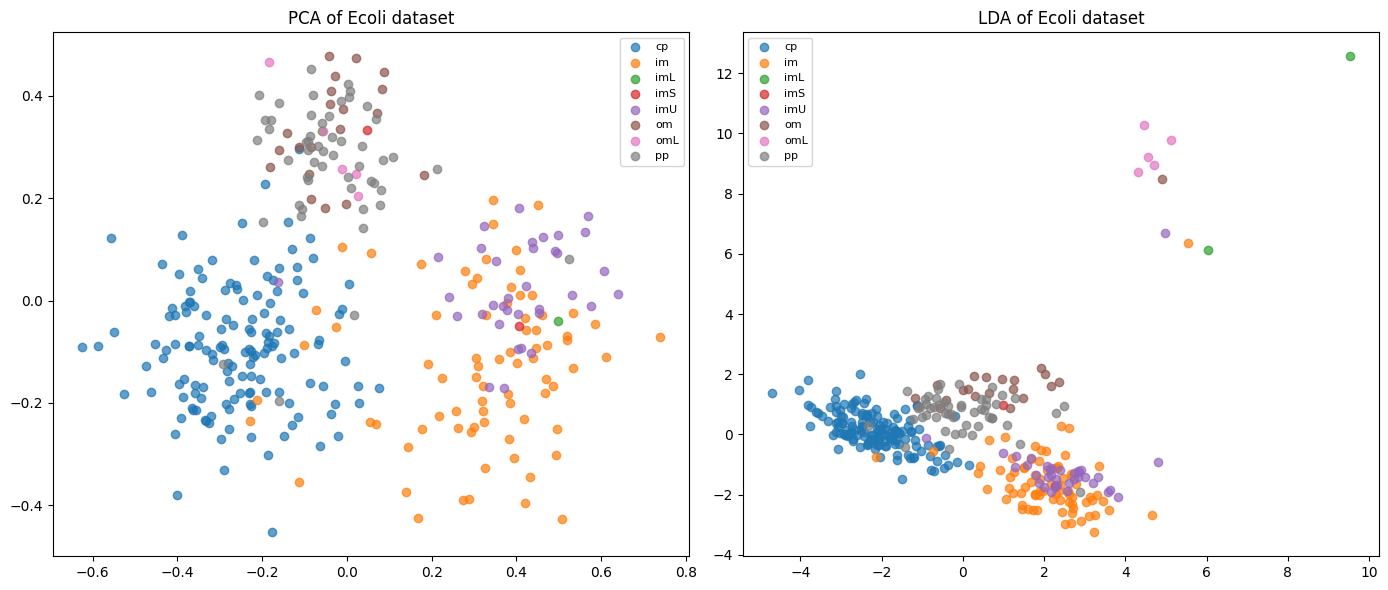

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import LabelEncoder

# Baca dataset Ecoli
df = pd.read_csv("ecoli.data", sep="\s+", header=None)

# Ambil fitur (kolom 1–7) dan label (kolom 8)
X = df.iloc[:, 1:8].values
y = df.iloc[:, 8].values

# Encode label string jadi angka
le = LabelEncoder()
y_encoded = le.fit_transform(y)
target_names = le.classes_

# PCA ke 2 dimensi
pca = PCA(n_components=2)
X_r = pca.fit(X).transform(X)

# LDA ke 2 dimensi
lda = LinearDiscriminantAnalysis(n_components=2)
X_r2 = lda.fit(X, y_encoded).transform(X)

# Variance explained PCA
print("Explained variance ratio (first two components):", pca.explained_variance_ratio_)

# Buat subplot agar ada jarak
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = plt.cm.tab10.colors

# Plot PCA
for color, i, target_name in zip(colors, range(len(target_names)), target_names):
    axes[0].scatter(X_r[y_encoded == i, 0], X_r[y_encoded == i, 1],
                    color=color, alpha=0.7, label=target_name)
axes[0].set_title("PCA of Ecoli dataset")
axes[0].legend(loc="best", shadow=False, scatterpoints=1, fontsize=8)

# Plot LDA
for color, i, target_name in zip(colors, range(len(target_names)), target_names):
    axes[1].scatter(X_r2[y_encoded == i, 0], X_r2[y_encoded == i, 1],
                    alpha=0.7, color=color, label=target_name)
axes[1].set_title("LDA of Ecoli dataset")
axes[1].legend(loc="best", shadow=False, scatterpoints=1, fontsize=8)

# Atur layout agar tidak berdempetan
plt.tight_layout()
plt.show()


## **Perisapan data untuk ADASYN**
1. Import library yang diperlukan untuk ADASYN **(from imblearn.over_sampling import ADASYN)**
2. Memisahkan fitur dan targe.
3. Analisis distribusi awal menggunakan **Counter()** untuk melihat ketidakseimbangan.

In [6]:
!pip install imbalanced-learn


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from imblearn.over_sampling import ADASYN
from collections import Counter
import pandas as pd

df = pd.read_csv("ecoli.data", sep=r"\s+", header=None)
print(df.head())

# Ambil fitur (kolom 1–7) dan target (kolom 8)
X = df.iloc[:, 1:8]
y = df.iloc[:, 8]

print("Distribusi kelas sebelum ADASYN:")
print(Counter(y))
print(f"Total sampel sebelum ADASYN: {len(y)}")
print(f"Jumlah fitur: {X.shape[1]}")


            0     1     2     3    4     5     6     7   8
0   AAT_ECOLI  0.49  0.29  0.48  0.5  0.56  0.24  0.35  cp
1  ACEA_ECOLI  0.07  0.40  0.48  0.5  0.54  0.35  0.44  cp
2  ACEK_ECOLI  0.56  0.40  0.48  0.5  0.49  0.37  0.46  cp
3  ACKA_ECOLI  0.59  0.49  0.48  0.5  0.52  0.45  0.36  cp
4   ADI_ECOLI  0.23  0.32  0.48  0.5  0.55  0.25  0.35  cp
Distribusi kelas sebelum ADASYN:
Counter({'cp': 143, 'im': 77, 'pp': 52, 'imU': 35, 'om': 20, 'omL': 5, 'imS': 2, 'imL': 2})
Total sampel sebelum ADASYN: 336
Jumlah fitur: 7


## **Implementasi ADASYN**

Pada saat saya mencoba menggunakan ADASYN, terjadi error karena pada sebagian kelas minoritas tidak memiliki tetangga dari kelas mayoritas, sehingga menimbulkan masalah division by zero atau tidak memenuhi default n_neighbors=5 dari ADASYN. Hal ini menunjukkan bahwa ADASYN tidak langsung cocok digunakan pada data saya. Namun, saya menemukan solusi yaitu dengan melakukan Randomoversampler sederhana terlebih dahulu agar distribusi kelas menjadi lebih seimbang. Setelah itu, barulah ADASYN dapat diterapkan untuk menghasilkan data sintetis yang lebih representatif.

**Bukti jika ADASYN memang gagal di coba**

In [10]:
from imblearn.over_sampling import ADASYN
from collections import Counter
import pandas as pd

# Baca dataset Ecoli
df = pd.read_csv("ecoli.data", sep="\s+", header=None)

# Ambil fitur (kolom 1–7) dan target (kolom 8)
X = df.iloc[:, 1:8]
y = df.iloc[:, 8]

# Inisialisasi ADASYN
adasyn = ADASYN(random_state=42, n_neighbors=2)

# Terapkan ADASYN pada data
X_resampled, y_resampled = adasyn.fit_resample(X, y)

print("Distribusi kelas setelah ADASYN:")
print(Counter(y_resampled))
print(f"Total sampel setelah ADASYN: {len(y_resampled)}")

# Konversi hasil ADASYN kembali ke DataFrame
columns_names = X.columns.tolist()
df_resampled = pd.DataFrame(X_resampled, columns=columns_names)
df_resampled['Class'] = y_resampled   # ganti 'Species' → 'Class'

print("\nContoh data sintetis yang dihasilkan ADASYN:")
print(df_resampled.tail(10))  # Tampilkan 10 baris terakhir


<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_20205/929993729.py:6: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv("ecoli.data", sep="\s+", header=None)
/tmp/ipykernel_20205/929993729.py:6: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv("ecoli.data", sep="\s+", header=None)


ValueError: Expected n_neighbors <= n_samples_fit, but n_neighbors = 3, n_samples_fit = 2, n_samples = 2

**ROS (RandomOverSampler)**

ROS digunakan pada tahap awal untuk menambah jumlah sampel pada kelas yang sangat sedikit (seperti imS, imL, dan omL). Tujuannya adalah agar distribusi kelas tidak terlalu timpang dan setiap kelas minoritas memiliki jumlah sampel minimal yang cukup. Dengan cara ini, algoritma ADASYN bisa berjalan tanpa error, karena ia membutuhkan tetangga dari kelas mayoritas untuk membuat sampel sintetis. Jadi, ROS berperan sebagai langkah awal penyeimbang sebelum dilakukan pembangkitan data sintetis yang lebih adaptif dengan ADASYN.

In [11]:
from imblearn.over_sampling import RandomOverSampler, ADASYN
from collections import Counter

# Data awal
print("Data sebelum ROS:", Counter(y))

# Step 1: RandomOverSampler
ros = RandomOverSampler(random_state=42)
X_ros, y_ros = ros.fit_resample(X, y)
print("Data setelah ROS:", Counter(y_ros))

# Step 2: ADASYN
adasyn = ADASYN(random_state=42, sampling_strategy="auto")
X_res, y_res = adasyn.fit_resample(X_ros, y_ros)
print("Sebelum ADASYN:", Counter(y_ros))
print("Setelah ADASYN:", Counter(y_res))


Data sebelum ROS: Counter({'cp': 143, 'im': 77, 'pp': 52, 'imU': 35, 'om': 20, 'omL': 5, 'imS': 2, 'imL': 2})
Data setelah ROS: Counter({'cp': 143, 'im': 143, 'imS': 143, 'imL': 143, 'imU': 143, 'om': 143, 'omL': 143, 'pp': 143})
Sebelum ADASYN: Counter({'cp': 143, 'im': 143, 'imS': 143, 'imL': 143, 'imU': 143, 'om': 143, 'omL': 143, 'pp': 143})
Setelah ADASYN: Counter({'cp': 143, 'im': 143, 'imS': 143, 'imL': 143, 'imU': 143, 'om': 143, 'omL': 143, 'pp': 143})


## Visualisai Perbandingan Distribusi

Berikut adalah Visualisasi Perbandingan sebelum dan sesudah proses penyeimbangan data,bisa dilihat data sebelum di seimbangkan dan sudah diseimbangkan.

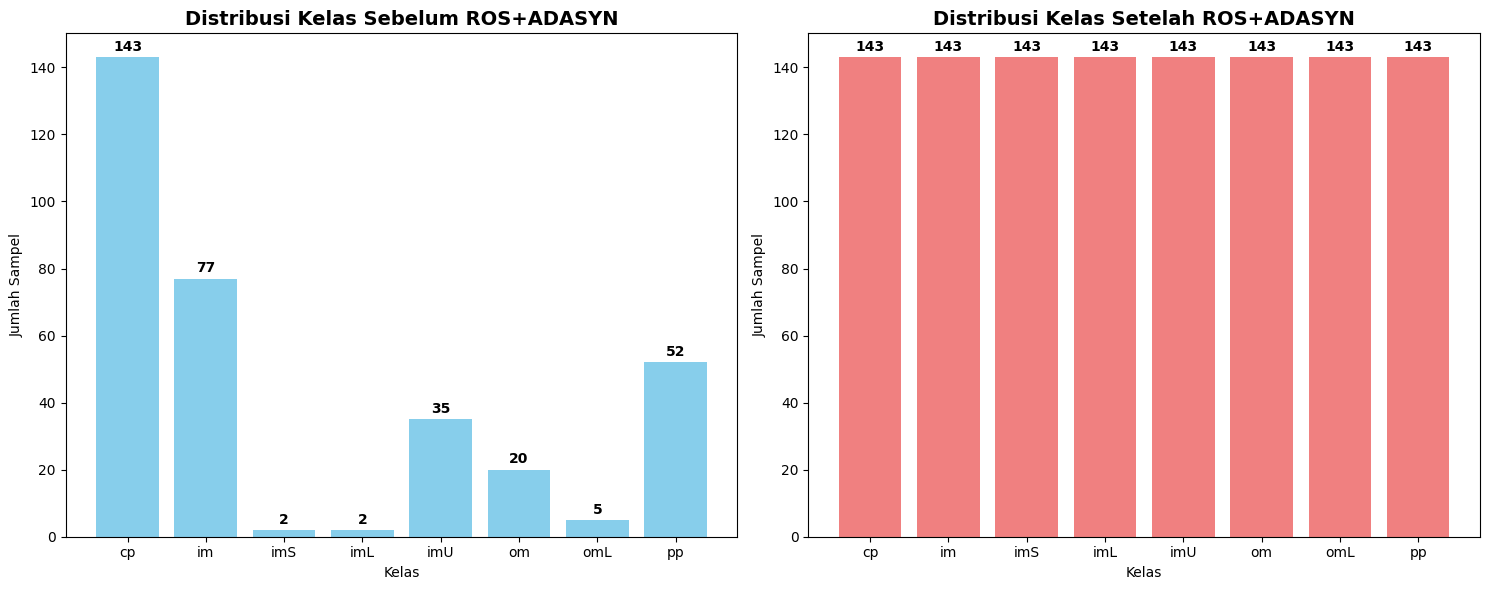


Tabel Perbandingan:
  Kelas  Sebelum ROS+ADASYN  Sesudah ROS+ADASYN  Sampel Sintetis Ditambahkan
0    cp                 143                 143                            0
1    im                  77                 143                           66
2   imS                   2                 143                          141
3   imL                   2                 143                          141
4   imU                  35                 143                          108
5    om                  20                 143                          123
6   omL                   5                 143                          138
7    pp                  52                 143                           91


In [12]:
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter

# Distribusi sebelum dan sesudah
before_counts = Counter(y)
after_counts = Counter(y_res)

species_names = list(before_counts.keys())
before_values = [before_counts[cls] for cls in species_names]
after_values = [after_counts[cls] for cls in species_names]

# Buat subplot
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot distribusi kelas sebelum ROS+ADASYN
bars1 = axes[0].bar(species_names, before_values, color='skyblue')
axes[0].set_title('Distribusi Kelas Sebelum ROS+ADASYN', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Jumlah Sampel')
axes[0].set_xlabel('Kelas')

# Tambahkan label nilai
for bar, value in zip(bars1, before_values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 str(value), ha='center', va='bottom', fontweight='bold')

# Plot distribusi kelas setelah ROS+ADASYN
bars2 = axes[1].bar(species_names, after_values, color='lightcoral')
axes[1].set_title('Distribusi Kelas Setelah ROS+ADASYN', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Jumlah Sampel')
axes[1].set_xlabel('Kelas')

# Tambahkan label nilai
for bar, value in zip(bars2, after_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 str(value), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Tabel perbandingan
print("\nTabel Perbandingan:")
comparison_df = pd.DataFrame({
    'Kelas': species_names,
    'Sebelum ROS+ADASYN': before_values,
    'Sesudah ROS+ADASYN': after_values,
    'Sampel Sintetis Ditambahkan': [after_values[i] - before_values[i] for i in range(len(species_names))]
})
print(comparison_df)


## Analisis PCA Data Setelah ADASYN

Visualisasi PCA Comparison:

Panel kiri: Scatter plot data asli dalam ruang PC1–PC2, masih menunjukkan ketidakseimbangan kelas.

Panel kanan: Scatter plot data setelah ADASYN dalam ruang PC1–PC2.

VISUALISASI PCA DATA SETELAH ADASYN


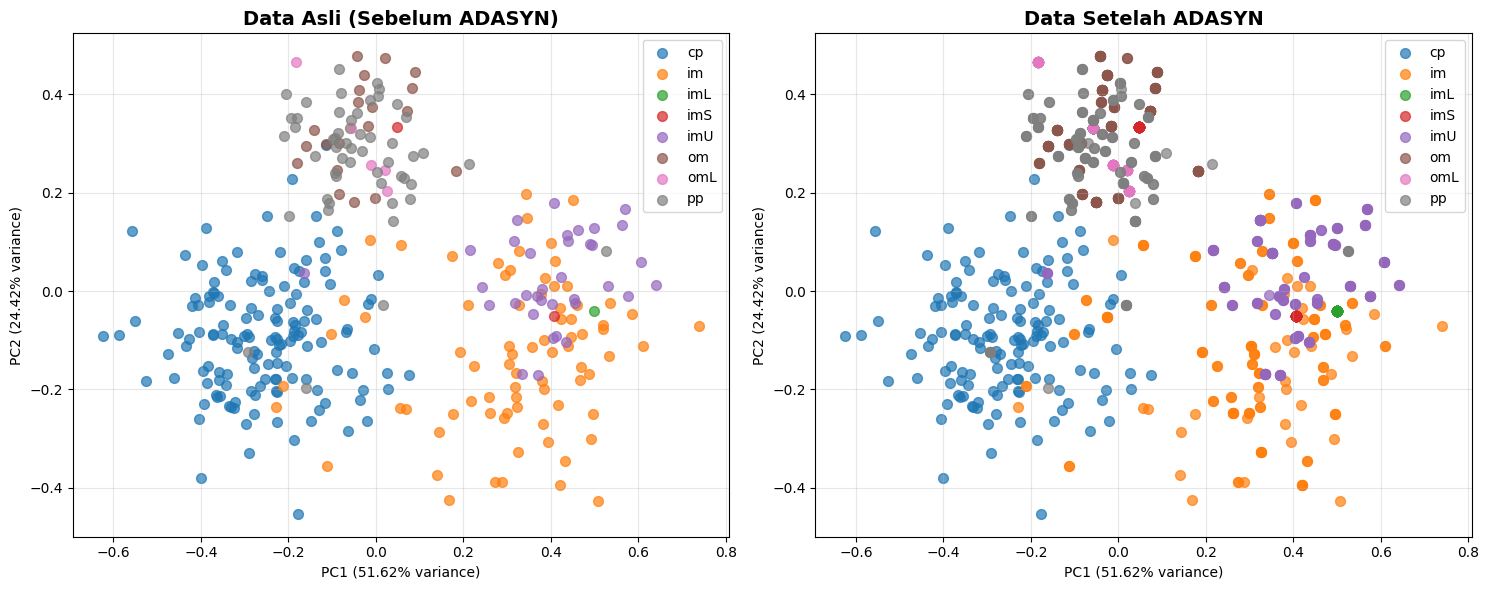


RINGKASAN HASIL ADASYN
• Data asli: 336 sampel dengan ketidakseimbangan kelas
• Data setelah ADASYN: 1144 sampel dengan kelas yang lebih seimbang
• Sampel sintetis yang dihasilkan: 808 sampel

Distribusi per kelas:
  - cp: sebelum 143, sesudah 143
  - im: sebelum 77, sesudah 143
  - imL: sebelum 2, sesudah 143
  - imS: sebelum 2, sesudah 143
  - imU: sebelum 35, sesudah 143
  - om: sebelum 20, sesudah 143
  - omL: sebelum 5, sesudah 143
  - pp: sebelum 52, sesudah 143


In [13]:
# Visualisasi distribusi fitur setelah ADASYN menggunakan PCA
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from collections import Counter
import matplotlib.pyplot as plt

print("VISUALISASI PCA DATA SETELAH ADASYN")

# Encode labels untuk visualisasi
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_res_encoded = le.transform(y_res)   # hasil ADASYN

# Terapkan PCA untuk visualisasi 2D
pca = PCA(n_components=2)
X_pca_original = pca.fit_transform(X)
X_pca_res = pca.transform(X_res)

# Buat subplot untuk perbandingan PCA
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Warna otomatis sesuai jumlah kelas
colors = plt.cm.tab10.colors
class_labels = le.classes_    # ambil nama kelas langsung dari dataset

# Plot data asli
for i, (color, label) in enumerate(zip(colors, class_labels)):
    mask = y_encoded == i
    axes[0].scatter(X_pca_original[mask, 0], X_pca_original[mask, 1],
                   c=[color], label=label, alpha=0.7, s=50)

axes[0].set_title('Data Asli (Sebelum ADASYN)', fontsize=14, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot data setelah ADASYN
for i, (color, label) in enumerate(zip(colors, class_labels)):
    mask = y_res_encoded == i
    axes[1].scatter(X_pca_res[mask, 0], X_pca_res[mask, 1],
                   c=[color], label=label, alpha=0.7, s=50)

axes[1].set_title('Data Setelah ADASYN', fontsize=14, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Ringkasan distribusi kelas
before_counts = Counter(y)
after_counts = Counter(y_res)

print("\nRINGKASAN HASIL ADASYN")
print(f"• Data asli: {len(y)} sampel dengan ketidakseimbangan kelas")
print(f"• Data setelah ADASYN: {len(y_res)} sampel dengan kelas yang lebih seimbang")
print(f"• Sampel sintetis yang dihasilkan: {len(y_res) - len(y)} sampel")

print("\nDistribusi per kelas:")
for label in class_labels:
    print(f"  - {label}: sebelum {before_counts[label]}, sesudah {after_counts[label]}")
